1. Add holding
2. View portfolio
3. Save porfolio
4. Load portfolio
5. Plot your portfolio history
6. Quit


Choose one of the following options: 5


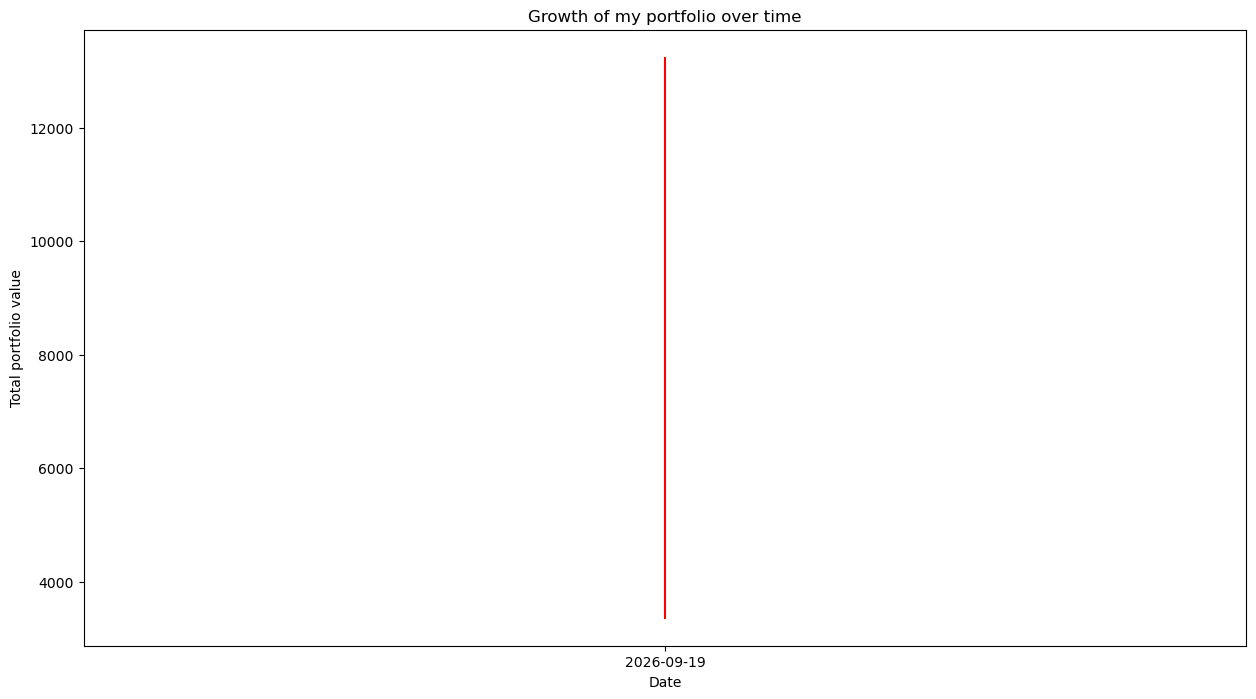

1. Add holding
2. View portfolio
3. Save porfolio
4. Load portfolio
5. Plot your portfolio history
6. Quit


In [ ]:
from dotenv import load_dotenv
#import load_dotenv so that I can store my API key elsewhere. 
import os
#import the os module, used here to access environment variables and to change the working directory. 
import requests
#import requests so that I can get the stock prices. 
import json
#import json so that I can save a json file and load the contents of that json file. 
from datetime import date
#import date so that I can get todays date to record my portfolio history. 
import matplotlib.pyplot as plt
#import matplot lib so that I can plot the total value of my portfolio over time. 

load_dotenv()
#reads the .env file and loads its contents into the environment, making FINNHUB_API_JEY available to os.getenv(). 
API_key = os.getenv("FINNHUB_API_KEY")
#using my API key that I got from fiinnhub.

class Holding:
#creates a class called "Holding".
    def __init__(self, ticker, shares, price):
        """
        Creates a function, __init__ means initialise so it will run automatically when
        the class is called. This function also contains all the parameters of the class
        and what each object should contain.
        """
        self.ticker = ticker
        #stores ticker on this specific object, so it can be accessed later via self.ticker.
        self.shares = shares
        #stores shares on this specific object, so it can be accessed later via self.shares.
        self.price = price
        #stores price on this specific object, so it can be accessed alter via self.price.
        self.current_price = None
        #set the current price to none because we figure that out on a function later on. 
    def cost_basis(self):
    #create a function called cost basis.
        return self.shares * self.price
        #the function returns the number of shares multiplied by the price.
    def update_price(self, new_price):
    #create a function called update_price.
        self.current_price = new_price
        #overwrites current_price with the new value passed in, replacing whatever it held before.
    def current_value(self):
    #creates a current_value function. 
        return self.shares * self.current_price
        #multiplies the number of shares with the current price.
    def gain_loss(self):
    #creates a function which shows our gain or loss. 
        return self.current_value() - self.cost_basis()
        #returns the difference between our current value and previous value of our stock. 

    def to_dict(self):
    #a function to add the parameters of a holding into a dictionary.
        return{"ticker": self.ticker, "shares": self.shares, "price": self.price}
        #adding the holding parameters to a dictionary.
def get_price(ticker):
    #function to get the current price of the stock.
    url = f"https://finnhub.io/api/v1/quote?symbol={ticker}&token={API_key}"
    #using my API key accessed vaia finnhub assigned to a variable.
    response = requests.get(url)
    #assignes a variable to getting the data from url. 
    data = response.json()
    #the response cam back as raw json text, .json() converts it into an actual python dictionary so we can access values by the key. 
    current_price = data['c']
    #gathers 'c' within the data which is the price and assigns it to a variable.
    if current_price == 0:
    #if the current price is equal to 0 then...
        print(f"Could not find price data for {ticker}. Check the ticker is correct.")
        #prints the f string to notify the user that their ticker of choice doesn't exist because price is 0.
        return None
        #return none, which means in main() this makes the user loop back to the beginning of the menu to try again. 
    return current_price
    #returns the current price so that it can be used outside of this function. 
    
class Portfolio:
#creates a class called Portfolio. 
    def __init__(self):
        """
        similar to previously __init__ means initialise so it will run atuomatically when 
        Portfolio is called. In this class we are trying to figure out the total value and gain
        of our portfolio made up of our holdings.
        """
        self.holdings = []
        #creates an empty list.
    def add_holding(self, holding):
    #creates a function that adds the holding into our empty self.holdings list. 
        self.holdings.append(holding)
        #adds holding into the empty list. 

    def total_cost_basis(self):
    #creates a function which determines the total value of the stock using its un-updated price. 
        total = 0
        #sets the total to 0.
        for holding in self.holdings:
        #I created a for loop to loop through the items within the self.holdings list. 
            total+= holding.cost_basis()
            #each time it loops through it will add the cost basis of each holding onto the total. 
        return total
        #returns the total value to be used elsewhere in my code. 

    def total_current_value(self):
    #creates a function which determines the total current value of your portfolio. 
        current_total = 0
        #sets the total to 0.
        for holding in self.holdings:
            #loops through the holdings in the self.holdings list. 
            current_total += holding.current_value()
            #each time it loops through it will add the holdings current value to the current_total. 
        return current_total
        #returns current total to be used elsewhere in my code. 

    def total_gain_loss(self):
        #creates a function which calculates the total gain or loss from the previous total value of the portfolio compared to the current total. 
        gain_loss_total = 0
        #sets the value to 0.
        for holding in self.holdings:
        #I created a for loop to loop through the holdings within the self.holdings list. 
            gain_loss_total += holding.gain_loss()
            #each time it loops through the holdings list it adds the gain or loss associated with each of the holdings. 
        return gain_loss_total
        #returns this total to be used elsewhere in my code.

    def to_dict(self):
        #creates a funcion which adds each of the holdings into a list called holdings_list. 
        holdings_list = []
        #creates an empty list within which all of the dictionaries will be held. 
        for holding in self.holdings:
        #created a loop to run through the list of holdings. 
            holding_dict = holding.to_dict()
            #each time it loops throughit converts each of the holdings into a dictionary. 
            holdings_list.append(holding_dict)
            #it adds such dictionaries into the empty list using .append().
        return holdings_list
        #returns the list containing the dicionaries to be used elsewhere in my code. 

def save_portfolio(portfolio, filename):
#a function outside of the portfolio class that creates a file to save my portfolio data to.
    data = portfolio.to_dict()
    #assigns the empty list in the to_dict function to a variable called data. 
    with open(filename, "w") as file:
    #opens a file with "w" which means to write only and it erases whatever was arleady in the file first. 
        json.dump(data, file)
        #then now we are writing in a new data file, we dump our "data" into it. 

def load_portfolio(filename):
#creates a fimctopm which loads back in the file we created in save_portfolio. 
    with open(filename, "r") as file:
    #we open this file with "r" which means we can only read the file. 
        data = json.load(file)
        #the file contains raw json text, json.load() reads it and converts it into a python list/dictionary so we can access the values. 

    portfolio = Portfolio()
    #creates a new, empty portfolio object to rebuild the saved holdings into. 
    for holding_dict in data:
    #loops through the list of dictionaries we just got from the file. 
        holding = Holding(holding_dict["ticker"], holding_dict["shares"], holding_dict["price"])
        #pulls the ticker, shares and price out of the dictionary, and uses them to rebuild a real Holding object.
        holding.update_price(get_price(holding_dict["ticker"]))
        #fetches a live price for this ticker and attaches it to holding, since current_price isn't saved in the file.
        portfolio.add_holding(holding)
        #adds the rebuild holding onto the new portfolio's holdings list

    return portfolio
    #returns the variable portfolio to be used to be printed so that I can read the file. 

def log_history(portfolio, filename):
#creates a function that logs the date and total value of my portfolio over time. 
    today = str(date.today())
    #gathers todays date using the imported method. 
    total_val = portfolio.total_current_value()
    #refers to a function that already calculates the total current value and assigns it to a variable. 
    try:
    #using try because the first ever time we run this code there will be no file to read so it would result in an error. 
        with open(filename, "r") as file:
        #reads the file (as long as it exists).
            history = json.load(file)
            #loads in the file and assigns it to a variable. 
            
    except FileNotFoundError:
    #this except is in the case that this is the first time we have ran the code and a file doesn't exist. 
        history = []
        #in the case a file doesn't exist an empty list has been created to be filled with the history. 

    history.append({"date": today, "total_value": total_val})
    #adds the dictionary containing todays date and total value of our portfolio into our empty list or our history file. 
    
    with open(filename, "w") as file:
    #opens the file to write.        
        json.dump(history, file)
        #dumps the dictionary/ies into the file that are contained in a list. 

def plot_history(filename):
#creates a function which aims to plot the growth of our portfolio. 
    with open(filename, "r") as file:
    #opens the file to read.
        history = json.load(file)
        #loads the file and assigns it to the history variable. 
    dates = []
    #creates an empty dates list. 
    values = []
    #creates an empty values list.
    for entry in history:
    #loops through the dictionaries within history. 
        dates.append(entry["date"])
        #uses the key of "date" to access the value associated with it, then appends it to the dates list. 
        values.append(entry["total_value"])
        #uses the key of "total_value" to access the value associated with it, then appends it to the values list. 

    plt.figure(figsize = (15,8))
    #sets the figure size. 
    plt.plot(dates, values, color = 'red', label = 'Growth')
    #actually plots the line graph, using dates on the x axis and values on the y axis. 
    plt.xlabel('Date')
    #labels the x axis 'Date'.
    plt.ylabel('Total portfolio value')
    #labels the y axis 'Total portfolio value'.
    plt.title('Growth of my portfolio over time')
    #sets the title name. 
    plt.show()
    #ensures all plt methods show on the line graph. 
            
        

def main():
#creates a main function.
    portfolio = Portfolio()
    #creates a new, empty Portfolio object to rebuild the saved holdings into. 
    while True:
    #creats a while loop that will keep printing the menu to the user until they press "5".
        print("1. Add holding")
        print("2. View portfolio")
        print("3. Save porfolio")
        print("4. Load portfolio")
        print("5. Plot your portfolio history")
        print("6. Quit")
        #above is the list of options presented to the user.
        choice = input("Choose one of the following options:")
        #input asks the user which option they would like to choose and their reply is assigned to choice. 
        if choice == "1":
        #if the choice is equal to 1 then the user has selected to add a holding. Note it is "1" rather than 1 as the input is a string. 
            ticker_choice = input("What ticker would you like to add: ")
            #asks what ticker the user would like to add to their portfolio, their answer is assigned to ticker_choice. 
            price = get_price(ticker_choice)
            #this refers to our get_price function which returned the current_price. 
            if price is None:
            #if the price that is returned is None this means the ticker the user chose doesnt exist otherwise the if statement is dismissed. 
                continue
                #if the price is none then it loops back to the beginning of the while loop within main().
            purchase_quantity = int(input(f"How many shares of {ticker_choice} did you buy: "))
            #asks the user how many shares of their chosen ticker they bought.
            purchase_price = float(input(f"What price did you purchase {ticker_choice} at: "))
            #asks the user how much the price was of their ticker of choice at the point of purchase. 
            new_holding = Holding(ticker_choice, purchase_quantity, purchase_price)
            #this puts all the information together into a new_holding, which includes the ticker, quantity and price of their holding. 
            new_holding.update_price(price)
            #this updates the current_price, that sits within our portfolio, each time the user refreshes.
            portfolio.add_holding(new_holding)
            #adds the holding to our empty portfolio. 
            print(f"{ticker_choice} added to your portfolio!")
            #a confirmation message that the holding has been added to the portfolio. 
            
        elif choice == "2":
        #if the user has input "2" then they would like to view their portfolio. 
            for holding in portfolio.holdings:
            #creates a for loop that loops through the holdings within our portfolio. 
                print(f"Ticker: {holding.ticker}, Purchase quantity: {holding.shares}, Purchase price: {holding.price}, "
                f"Current price: {holding.current_price}")
                #prints the attributes of the holding. 
            print(f"Total cost basis: {portfolio.total_cost_basis()}, Total current value: {portfolio.total_current_value()}, "
            f"Total gain or loss: {portfolio.total_gain_loss()}")
            #prints the totals for the portfolio as a whole rather than each holding. 
        elif choice == "3":
        #if the user input is "3" then they would like to save the portfolio as a file. 
            user_filename = input("What would you like to name the file? ")
            #asks the user what they would like to name the file and assigns the answer to user_filename. 
            save_portfolio(portfolio, user_filename)
            #refers to the save_portfolio function and passes the parameters. 
            log_history(portfolio, "history.json")
        elif choice == "4":
        #if the choice is equal to "4" then the user would like to load a file. 
            file_to_load = input("What file would you like to view? ")
            #the user is asked what file they would like to load and their answer is assigned to file_to_load.
            portfolio = load_portfolio(file_to_load)
            #refers to the load_portfolio function created earlier and file_to_load is passed as a parameter. 
            print(f"Loaded portfolio from {file_to_load}")
            # a confirmation message to let the user know the file has been loaded and is ready to be viewed. 
        elif choice == "5":
        #if the choice is equal to "5" the user would like to plot their portfolio's history. 
            os.chdir("Creating a portfolio")
            #directs python to look in the correct file for the json file containing the portfolio history. 
            plot_history("history.json")
            #refers to the function created earlier that will plot the portfolio's history. 
        elif choice == "6":
        #if the choice is equal to "6" then they would like to quit. 
            break
            #this breaks the while loop created at the beginning of main. 
        else:
            #if all the if/elif statements are not triggered then the user has input an invalid input (!= 1-5). 
            print("invalid input, please try again.")
            #prints an error statement.
            continue
            #loops back to the start of the while loop in main(). 

main()
#calls the main function. 